# Multivariate Analysis
-  More than > 2 variable

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We load the pickle file so we have the correct data type

# df = pd.read_pickle('data_MPG_clean.pkl')

# or use csv file
df = pd.read_csv('data_MPG.csv')

In [3]:
# categorical and numerical columns

cat_columns = ["origin", "cylinders", "model_year"]
num_columns = ["mpg", "displacement", "horsepower", "weight", "acceleration"]

# Faceted Multivariate Analysis (Small Multiples)

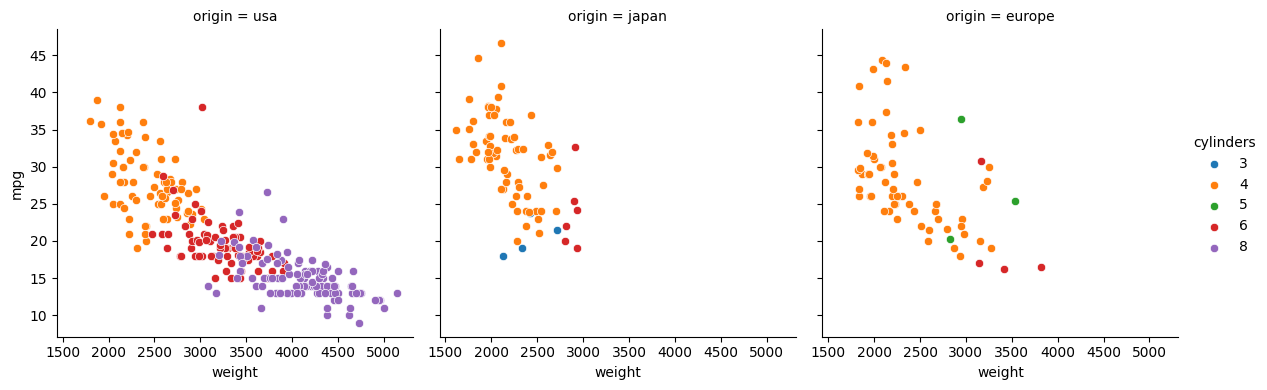

In [4]:
# origin vs cylinders vs weight vs mpg

g = sns.FacetGrid(
    data=df,
    col="origin",
    hue="cylinders",
    height=4,
    aspect=1
)
g.map(sns.scatterplot, "weight", "mpg")
g.add_legend()
plt.show()

# observ: USA does not have 3 clinder or 5 cylinders carts
# Japanese cars do not have 5 cylinders

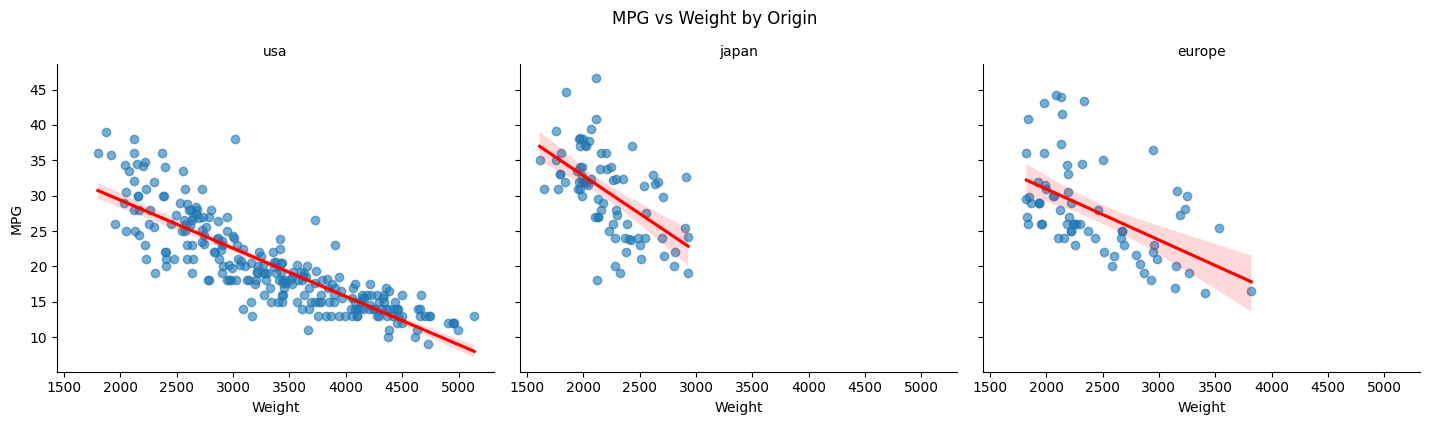

In [5]:
# Linear regression line

g = sns.FacetGrid(
    data=df,
    col="origin",
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.map(
    sns.regplot,
    "weight",
    "mpg",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

g.set_axis_labels("Weight", "MPG")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("MPG vs Weight by Origin", y=1.05)

plt.show()

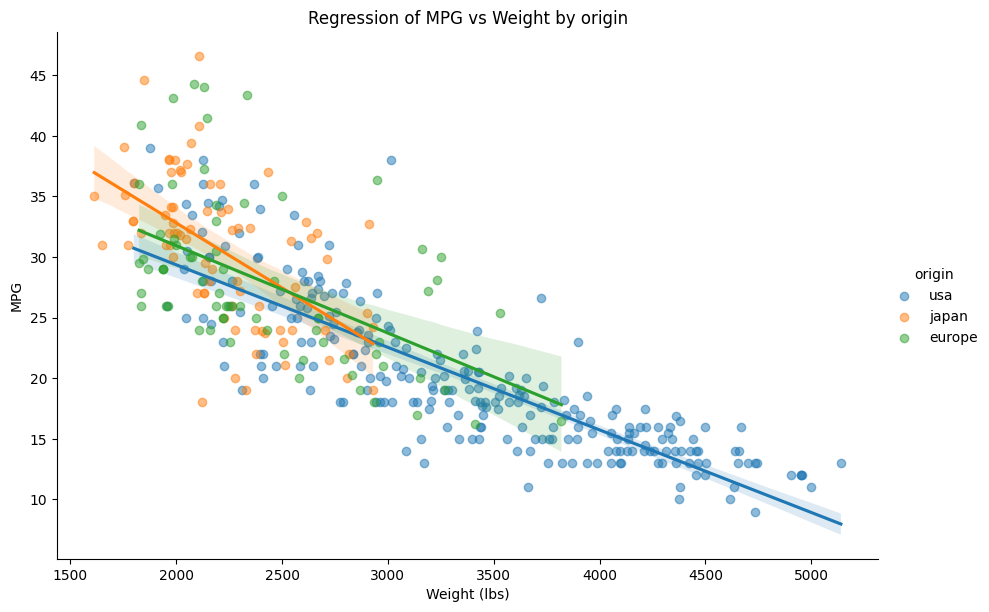

In [6]:
# Compare MPG vs Weight slopes across cylinders/origiin

# Regression with separate slopes for each cylinder group
hue_col = "origin" # or use origin, cylinders
sns.lmplot(data=df,
    x="weight", y="mpg",
    hue=hue_col, 
    aspect=1.5, 
    height=6, scatter_kws={"alpha":0.5})

plt.title(f"Regression of MPG vs Weight by {hue_col}")
plt.xlabel("Weight (lbs)")
plt.ylabel("MPG")
plt.show()


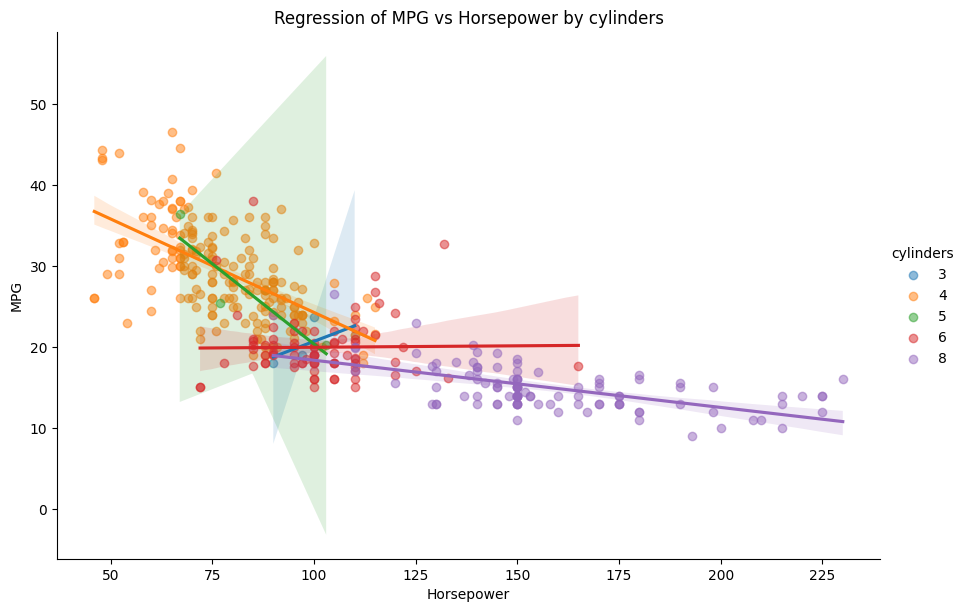

In [7]:

hue_col = "cylinders" # or use origin, cylinders
sns.lmplot(
    data=df,
    x="horsepower", y="mpg",
    hue=hue_col,
    aspect=1.5, height=6, scatter_kws={"alpha":0.5},
    palette="tab10"
)

plt.title(f"Regression of MPG vs Horsepower by {hue_col}")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

# Observ: For 3 cylinder cars from Japan, as horsepower increases, MPG also increases

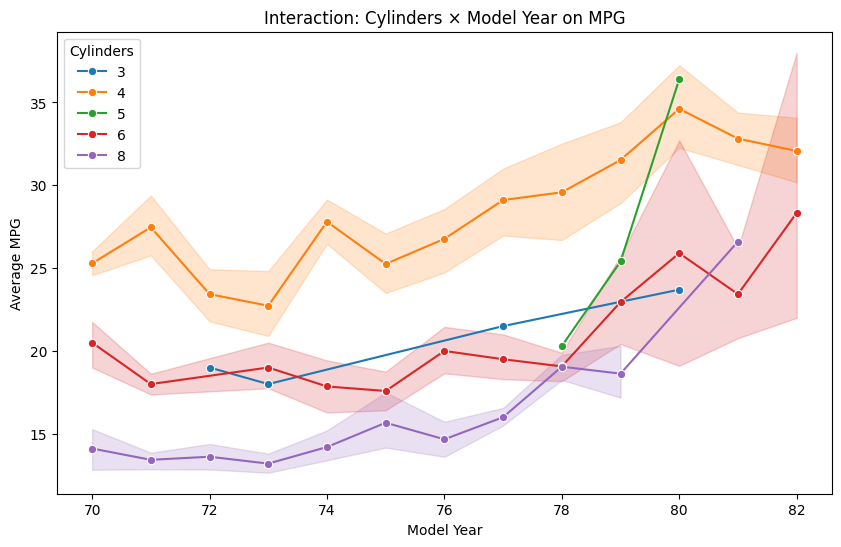

In [8]:
# step1: Interaction: Cylinders × Model Year on MPG
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="model_year",
    y="mpg",
    hue="cylinders",
    estimator="mean",
    marker="o",
    palette="tab10"
)

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

# Some values are overlapping....giving me headache...

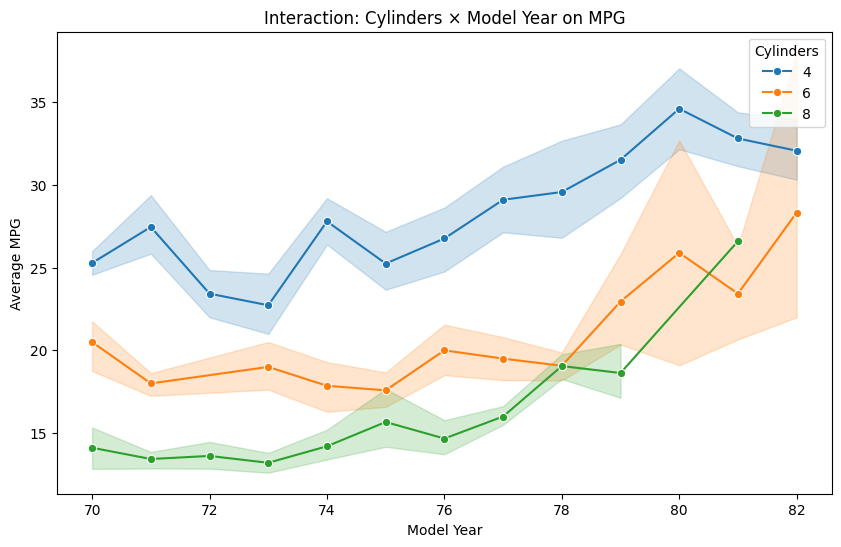

In [9]:
# step2: Perform filtering. Do only those that are visible with cylinder 4, 6, 8
mask = (df["cylinders"] == 8) | (df["cylinders"] == 6) | (df["cylinders"] == 4)

plt.figure(figsize=(10,6))
sns.lineplot(
    x="model_year", y="mpg", 
    hue="cylinders", 
    data=df[mask], 
    estimator="mean", marker="o",
    palette="tab10"
)

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

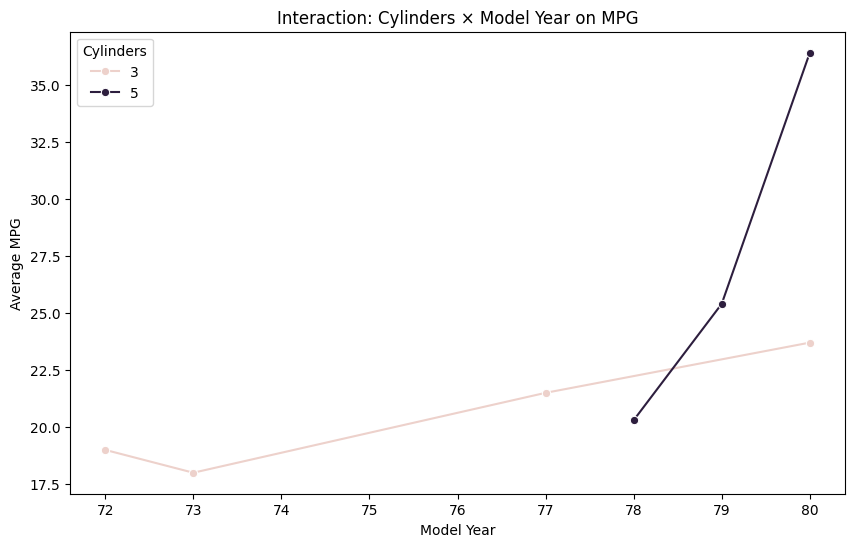

In [10]:
# step3: Perform filtering. Lets do the remaining ones with cylinder 3 and 5
mask = (df["cylinders"] == 3) | (df["cylinders"] == 5)

plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", hue="cylinders", data=df[mask], estimator="mean", marker="o")

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

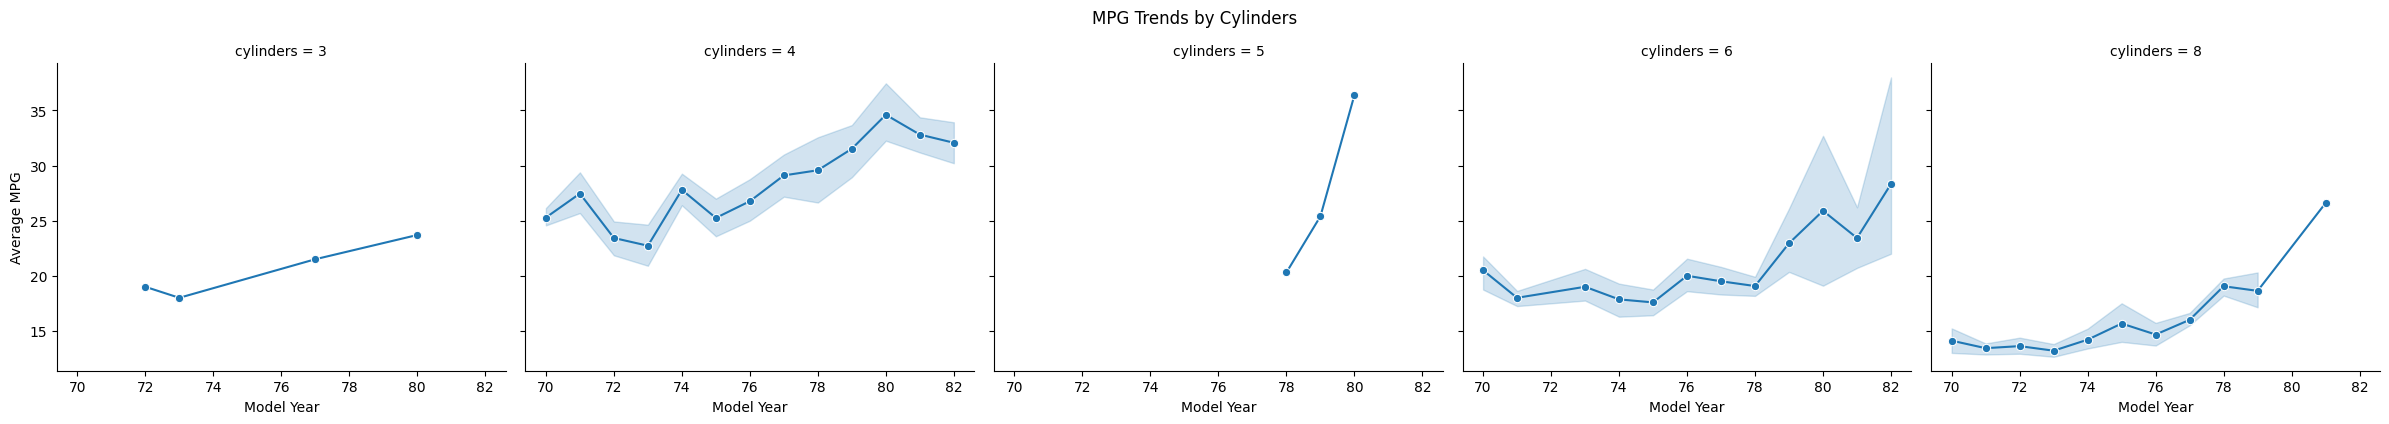

In [11]:
#step4: Lets do facetgrid
g = sns.FacetGrid(df, col="cylinders", height=4, aspect=1.2)
g.map(sns.lineplot, "model_year", "mpg", estimator="mean", marker="o")
g.set_axis_labels("Model Year", "Average MPG")
g.fig.suptitle("MPG Trends by Cylinders", y=1.05)
plt.show()

# observation: This plot is better than above.

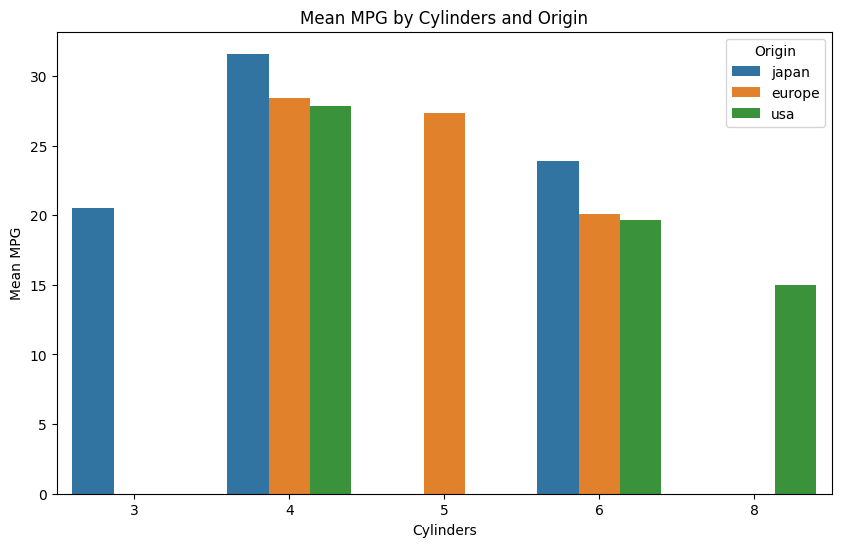

In [12]:
# grouped barplot is great for comparing mpg across cylinder counts, broken down by origin.
plt.figure(figsize=(10,6))
sns.barplot(x="cylinders", y="mpg", hue="origin", data=df, estimator="mean", errorbar=None)

plt.title("Mean MPG by Cylinders and Origin")
plt.xlabel("Cylinders")
plt.ylabel("Mean MPG")
plt.legend(title="Origin")
plt.show()

# observ: No data for 3 cyl cars from USA and Europe
# No data for 5 cyl cars from USA and Japan
# No data for 8 cyl cars from Europe and Japan